#Import all required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras

## Read Data-set

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/train.csv")
data.head(10)

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,1,0,0,0,0,0,1,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,3
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,5,0,0,0,0,1,0,0,0,0,...,0,0,0,133,167,73,0,0,0,2
6,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
7,7,0,0,0,0,0,1,1,0,0,...,0,3,0,82,237,231,70,0,0,2
8,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
9,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


This data-set about Fashion Images, all Images are in Flattened Pixel Values, we must convert into 2D Matrix Like (Num_of_Images,28,28,1) But first we must remove column "id".

In [ ]:
data = data.drop(columns=['id'])
data.head(10)

,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,0,0,0,0,0,1,0,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,22,...,0,0,0,133,167,73,0,0,0,2
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
7,0,0,0,0,0,1,1,0,0,0,...,0,3,0,82,237,231,70,0,0,2
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


Then we split data into input and output X = "All fetures columns" and Y = "labels column"

In [ ]:
x = data.iloc[:,:-1].values
y = data.iloc[:,-1].values

Check shape of X and Y

In [ ]:
x.shape, y.shape

((55000, 784), (55000,))

This is flatten feture of images CNN does't support, we must change into 2D matrix.

In [ ]:
x= x.reshape(-1,28,28,1)
x.shape

(55000, 28, 28, 1)

Here we have 55000 sample of images of fashion which size is (28,28) and grayscale image.

In [ ]:
x_train = x
y_train = y
x_train

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [ ]:
x_train[0]

array([[[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0]],

       [[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0]],

       [[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
      

In [ ]:
y_train[0]

np.int64(9)

## Show Image

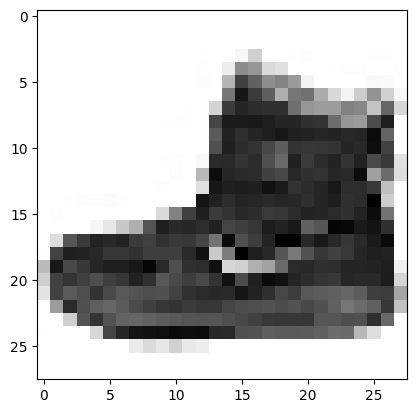

In [ ]:
plt.imshow(x_train[0], cmap = "Greys")

In [ ]:
y_train[0]

np.int64(9)

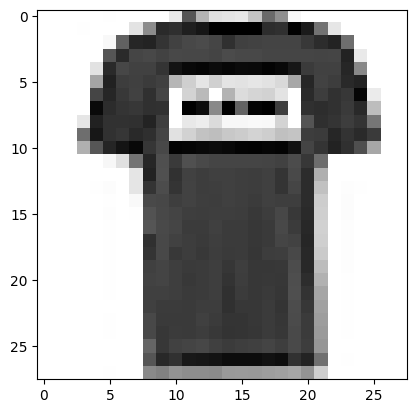

In [ ]:
plt.imshow(x_train[1], cmap = "Greys")

In [ ]:
y_train[1]

np.int64(0)

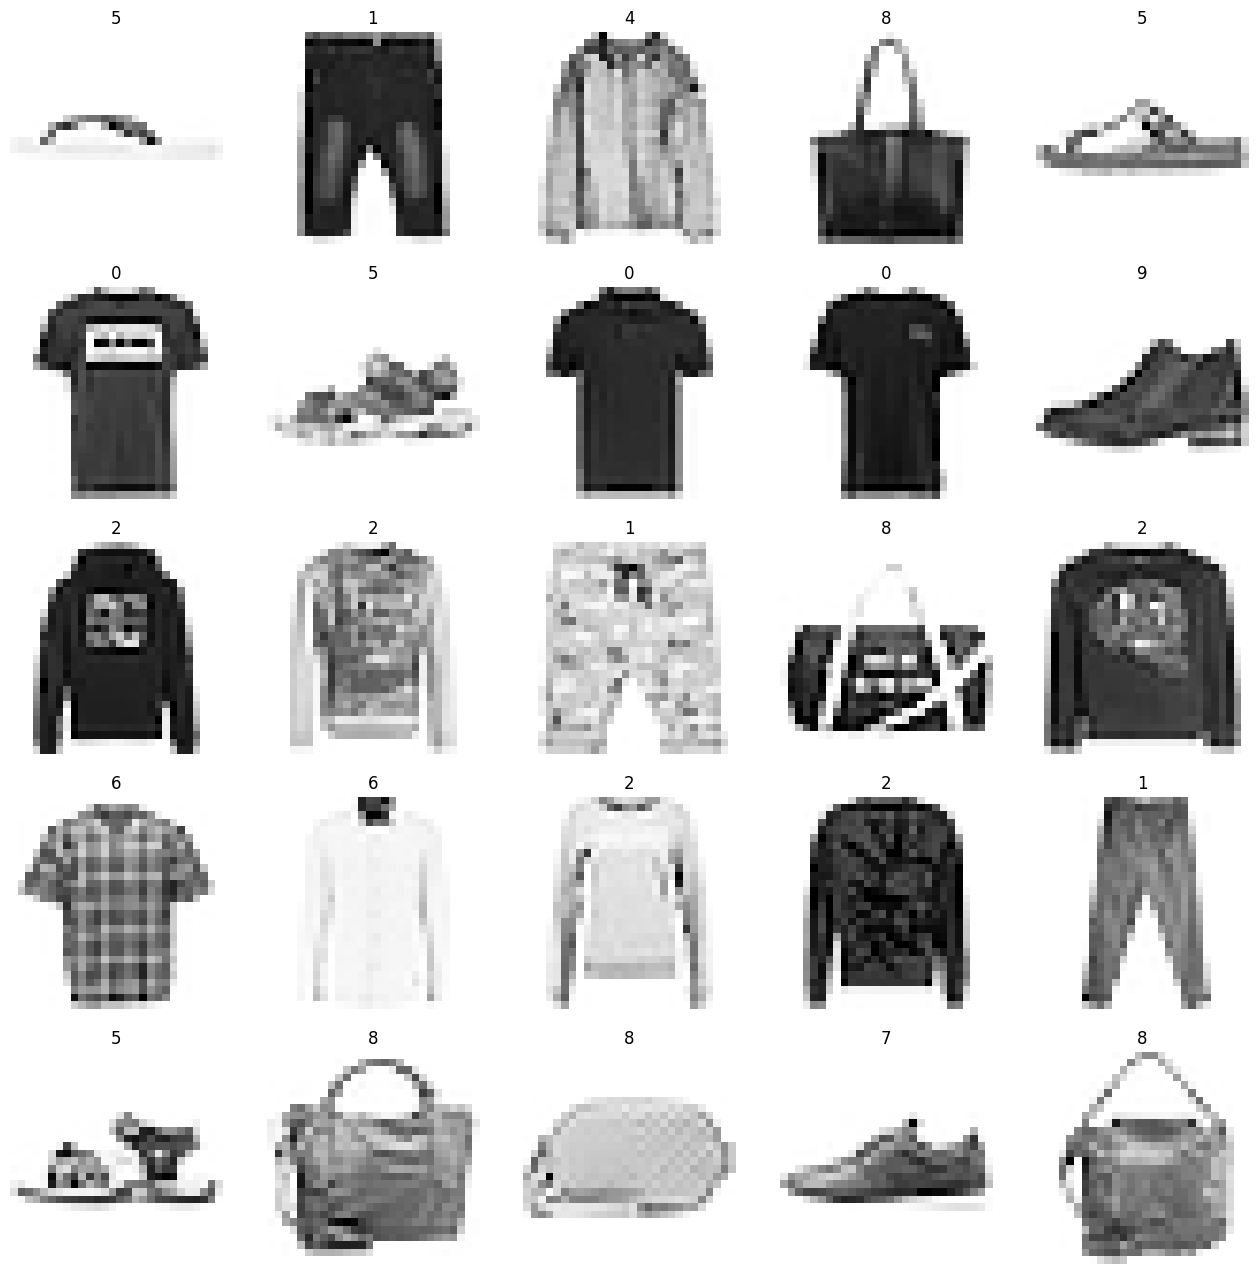

In [ ]:
plt.figure(figsize = (16,16))
j = 1
for i in np.random.randint(0,1000,25):
  plt.subplot(5,5,j)
  j+= 1
  plt.imshow(x_train[i], cmap = 'Greys')
  plt.axis("off")
  plt.title(y_train[i])

## Normalize Pixel Values for better work of CNN

In [ ]:
x_train = x_train/255.0

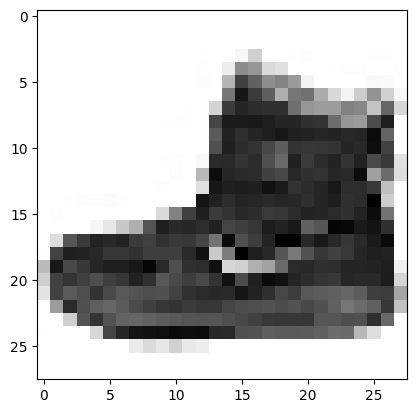

In [ ]:
plt.imshow(x_train[0], cmap = "Greys")

## Split Data-Set

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state=42)

In [ ]:
x_val.shape, y_val.shape

((11000, 28, 28, 1), (11000,))

In [ ]:
x_train.shape, y_train.shape

((44000, 28, 28, 1), (44000,))

# CNN Model Building

In [ ]:
model=keras.models.Sequential([keras.layers.Conv2D(filters =32,kernel_size=3, strides=(1,1), padding='valid', activation='relu', input_shape=[28,28,1]),
                         keras.layers.MaxPool2D(pool_size=(2,2)),
                         # Layers 2
                         keras.layers.Conv2D(filters = 64, kernel_size = 3, strides =(1,1), padding='same', activation='relu'),
                         keras.layers.MaxPool2D(pool_size=(2,2)),
                         # Layer 3
                         keras.layers.Conv2D(filters = 128, kernel_size = 3, strides = (1,1),padding='same', activation='relu'),
                         keras.layers.AveragePooling2D(pool_size=(2,2)),
                         # Convert into Flatten
                         keras.layers.Flatten(),
                         # ANN Model
                         keras.layers.Dense(units=100, activation='relu'),
                         keras.layers.Dense(units=100, activation='relu'),
                         keras.layers.Dense(units=100, activation='relu'),
                         # Output Layer
                         keras.layers.Dense(units=10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 3, 3, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,182 (895.24 KB)

 Trainable params: 229,182 (895.24 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import optimizers
# Momentom
opt_momentum = optimizers.SGD(learning_rate = 0.01, momentum = 0.9)
# NAG
opt_nag = optimizers.SGD(learning_rate = 0.01, momentum = 0.9, nesterov = True)
# Adam
opt_adam = optimizers.Adam(learning_rate = 0.001)

In [ ]:
import tensorflow as tf
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
class WeightsHistory(tf.keras.callbacks.Callback):
  def on_train_begin(self, logs = None):
    self.weights_list = []
  def on_epoch_end(self, epoch, logs = None):
    w_all = np.concatenate([w.flatten() for w in self.model.get_weights()])
    self.weights_list.append(w_all)
weight_callback = WeightsHistory()

In [ ]:
model.compile(optimizer=opt_adam,loss='sparse_categorical_crossentropy', metrics= ['accuracy'])

In [ ]:
output = model.fit(x_train, y_train, epochs=50, batch_size=512, verbose=1, validation_data=(x_val, y_val), callbacks=[weight_callback])

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 68s 758ms/step - accuracy: 0.6208 - loss: 1.0278 - val_accuracy: 0.7445 - val_loss: 0.6386
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 66s 768ms/step - accuracy: 0.7753 - loss: 0.5872 - val_accuracy: 0.8061 - val_loss: 0.5367
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 84s 787ms/step - accuracy: 0.8126 - loss: 0.5031 - val_accuracy: 0.8124 - val_loss: 0.5047
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 63s 734ms/step - accuracy: 0.8404 - loss: 0.4399 - val_accuracy: 0.8410 - val_loss: 0.4393
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 750ms/step - accuracy: 0.8539 - loss: 0.4047 - val_accuracy: 0.8558 - val_loss: 0.3897
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 751ms/step - accuracy: 0.8675 - loss: 0.3638 - val_accuracy: 0.8687 - val_loss: 0.3555
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 808ms/step - accuracy: 0.8753 - loss: 0.3436 - val_accuracy: 0.8750 - val_loss: 0.3482
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 76s 740ms/step - accuracy: 0.8809 - loss: 0.3259 - val_accu

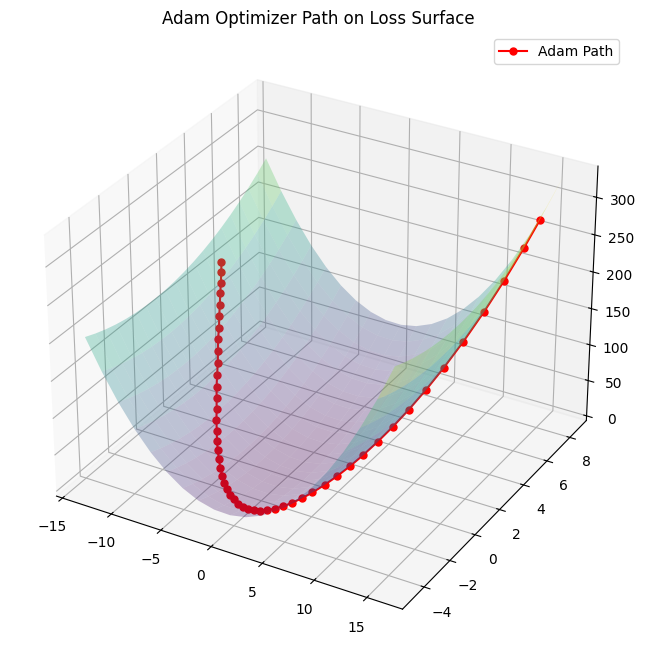

In [ ]:
# Convert All weights into 2D
all_weights = np.array(weight_callback.weights_list)
pca = PCA(n_components = 2)
weight_2d = pca.fit_transform(all_weights)

# Grid serface
x = np.linspace(weight_2d[:, 0].min()-1, weight_2d[:,0].max()+1, 20)
y = np.linspace(weight_2d[:, 1].min()-1, weight_2d[:, 1].max() +1, 20)
x, y = np.meshgrid(x,y)

# Cereting Dummy Loss serface
z = (x**2 + y**2)

# Ploting 3D
fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111, projection = "3d")

# Surface plot
surf = ax.plot_surface(x,y,z, cmap = "viridis", alpha = 0.3)

traj_x = weight_2d[:, 0]
traj_y = weight_2d[:, 1]
traj_z = (traj_x**2 + traj_y**2)

ax.plot(traj_x, traj_y, traj_z, color = 'red', marker = 'o', markersize = 5, label = "Adam Path")
ax.set_title('Adam Optimizer Path on Loss Surface')
plt.legend()
plt.show()

In [ ]:
y_pred_check = model.predict(np.expand_dims(x_val[0], axis = 0)).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


In [ ]:
y_pred_check

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]], dtype=float32)

In [ ]:
np.argmax(y_pred_check)

np.int64(8)

In [ ]:
y_val[0]

np.int64(8)

In [ ]:
y_pred_adam = model.predict(x_val).round(3)
y_pred_adam

344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[0.   , 0.   , 0.   , ..., 0.   , 0.997, 0.   ],
       [0.   , 1.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 1.   ],
       ...,
       [0.   , 0.   , 0.993, ..., 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , ..., 1.   , 0.   , 0.   ],
       [0.035, 0.   , 0.006, ..., 0.   , 0.   , 0.   ]], dtype=float32)

In [ ]:
model.evaluate(x_val, y_val)

344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9125 - loss: 0.2935


[0.2934914827346802, 0.9125454425811768]

344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step


/tmp/ipykernel_11492/1980122016.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


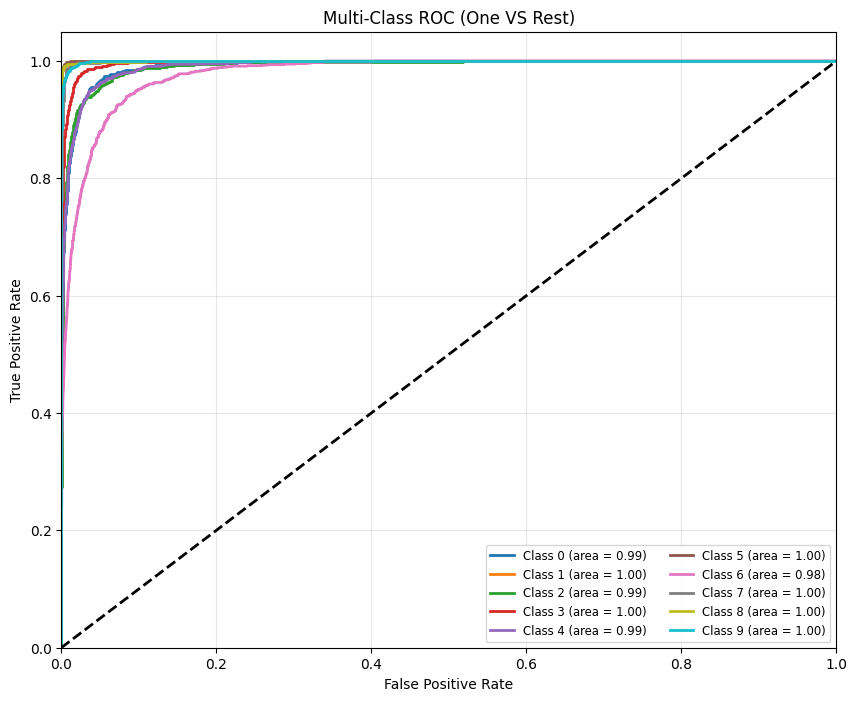

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.arange(10)
y_test_binarized = label_binarize(y_val, classes = classes)
n_classes = len(classes)

y_score = model.predict(x_val)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
  roc_auc[i] = auc(fpr[i],tpr[i])

# Plotting
plt.figure(figsize=(10,8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
  plt.plot(fpr[i], tpr[i], color= colors(i), lw = 2, label = f"Class {i} (area = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1], 'k--', lw = 2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC (One VS Rest)")
plt.legend(loc = "lower right", fontsize = "small", ncol = 2)
plt.grid(alpha = 0.3)
plt.show()

# Visulize Model's Output

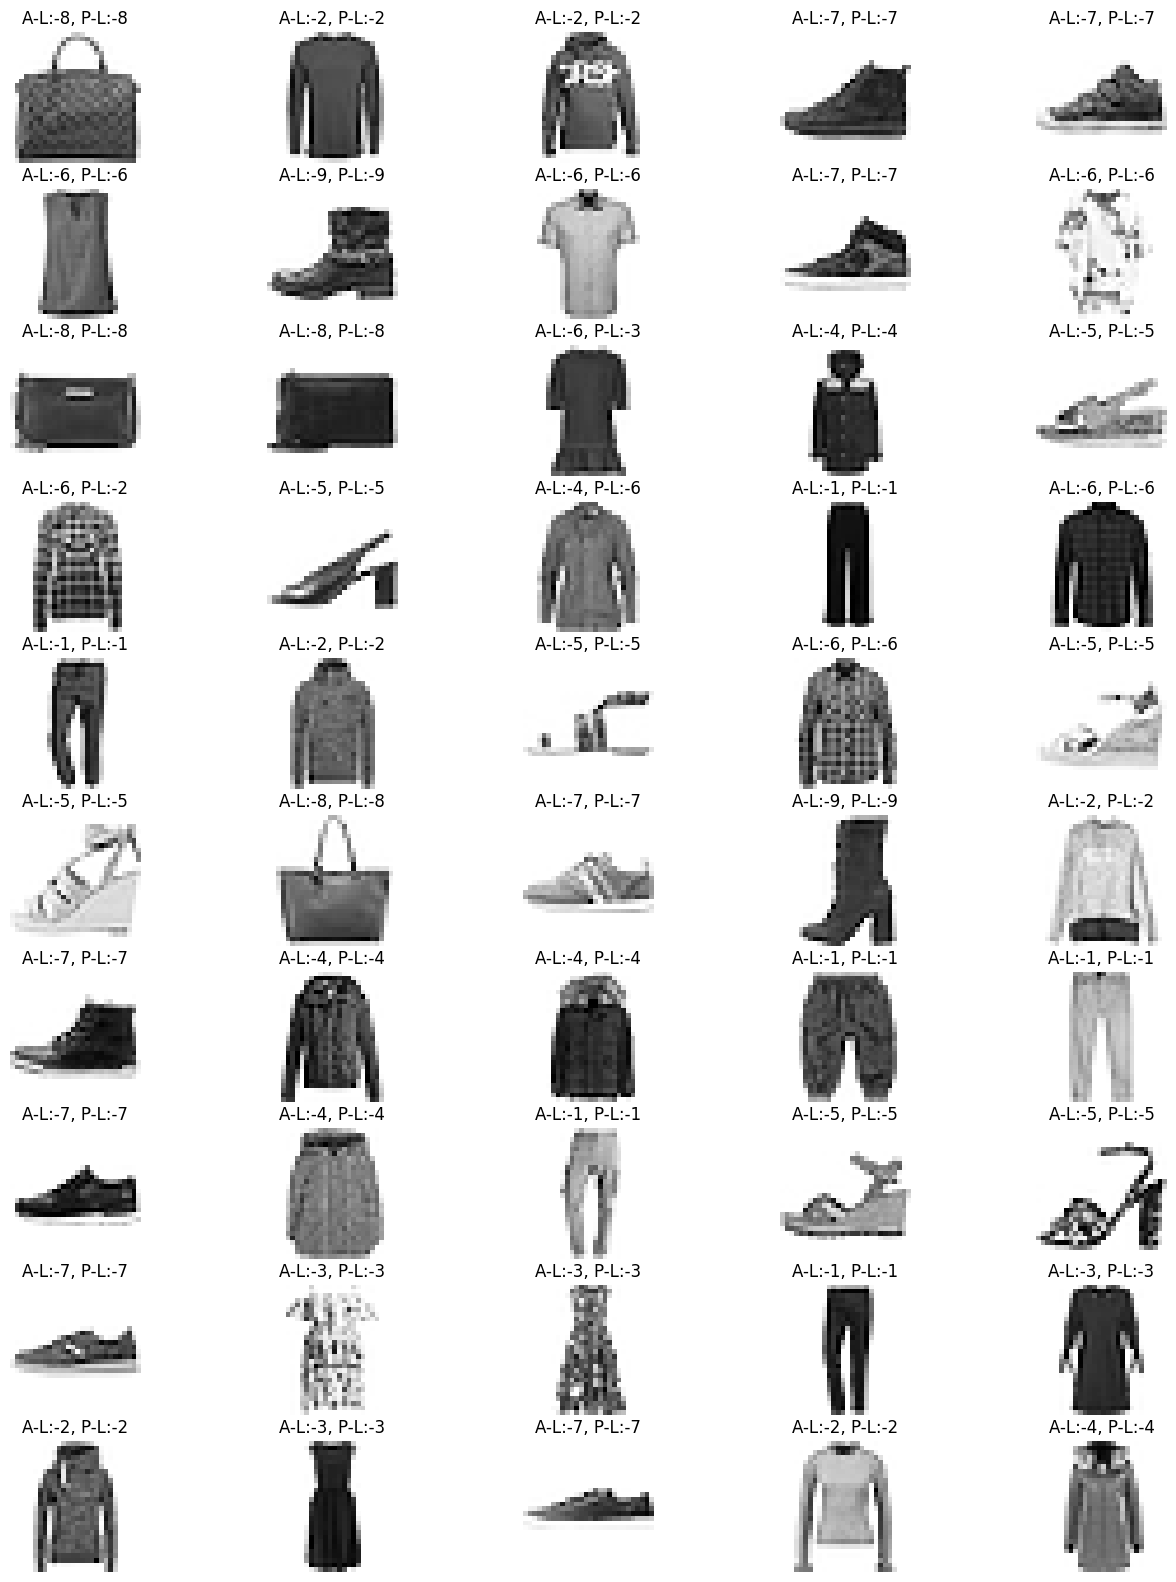

In [ ]:
plt.figure(figsize=(16,20))
j = 1
for i in np.random.randint(0,11000,50):
  plt.subplot(10,5,j)
  j += 1
  plt.imshow(x_val[i], cmap = 'Greys')
  plt.title(f"A-L:-{y_val[i]}, P-L:-{np.argmax(y_pred_adam[i])}")
  plt.axis('off')

<Axes: >

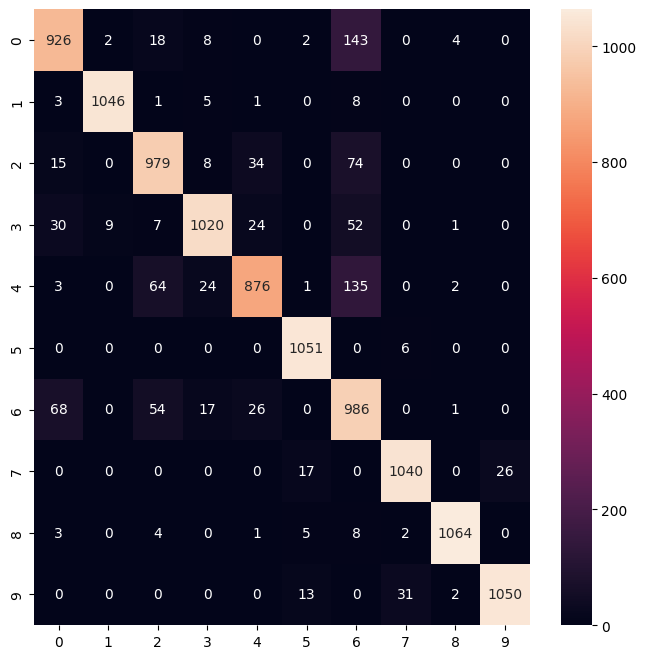

In [ ]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8,8))
y_pred_label = [np.argmax(label) for label in y_pred_adam]
cm = confusion_matrix(y_val, y_pred_label)

sns.heatmap(cm, annot = True, fmt = 'd')

In [ ]:
from sklearn.metrics import classification_report
cr = classification_report(y_val, y_pred_label)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1103
           1       0.99      0.98      0.99      1064
           2       0.87      0.88      0.88      1110
           3       0.94      0.89      0.92      1143
           4       0.91      0.79      0.85      1105
           5       0.97      0.99      0.98      1057
           6       0.70      0.86      0.77      1152
           7       0.96      0.96      0.96      1083
           8       0.99      0.98      0.98      1087
           9       0.98      0.96      0.97      1096

    accuracy                           0.91     11000
   macro avg       0.92      0.91      0.92     11000
weighted avg       0.92      0.91      0.91     11000



# Model Using Momentum Optimizer

In [ ]:
model_momentum=keras.models.Sequential([keras.layers.Conv2D(filters =32,kernel_size=3, strides=(1,1), padding='valid', activation='relu', input_shape=[28,28,1]),
                         keras.layers.MaxPool2D(pool_size=(2,2)),
                         # Layers 2
                         keras.layers.Conv2D(filters = 64, kernel_size = 3, strides =(1,1), padding='same', activation='relu'),
                         keras.layers.MaxPool2D(pool_size=(2,2)),
                         # Layer 3
                         keras.layers.Conv2D(filters = 128, kernel_size = 3, strides = (1,1),padding='same', activation='relu'),
                         keras.layers.AveragePooling2D(pool_size=(2,2)),
                         # Convert into Flatten
                         keras.layers.Flatten(),
                         # ANN Model
                         keras.layers.Dense(units=100, activation='relu'),
                         keras.layers.Dense(units=100, activation='relu'),
                         keras.layers.Dense(units=100, activation='relu'),
                         # Output Layer
                         keras.layers.Dense(units=10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
class WeightsHistory1(tf.keras.callbacks.Callback):
  def on_train_begin(self, logs = None):
    self.weights_list1 = []
  def on_epoch_end(self, epoch, logs = None):
    w_all = np.concatenate([w.flatten() for w in self.model.get_weights()])
    self.weights_list1.append(w_all)
weight_callback1 = WeightsHistory1()

In [ ]:
opt_momentum = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

In [ ]:
model_momentum.compile(optimizer=opt_momentum,loss='sparse_categorical_crossentropy', metrics= ['accuracy'], jit_compile= False)

In [ ]:
model_momentum.fit(x_train, y_train, epochs=50, batch_size=512, verbose=1, validation_data=(x_val, y_val), callbacks = [weight_callback1])

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 736ms/step - accuracy: 0.3755 - loss: 1.9652 - val_accuracy: 0.5530 - val_loss: 1.3139
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 63s 731ms/step - accuracy: 0.6493 - loss: 0.9100 - val_accuracy: 0.6842 - val_loss: 0.8378
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 732ms/step - accuracy: 0.7099 - loss: 0.7569 - val_accuracy: 0.7075 - val_loss: 0.7545
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 723ms/step - accuracy: 0.7452 - loss: 0.6716 - val_accuracy: 0.7124 - val_loss: 0.7014
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 745ms/step - accuracy: 0.7596 - loss: 0.6282 - val_accuracy: 0.7591 - val_loss: 0.6060
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 80s 724ms/step - accuracy: 0.7756 - loss: 0.5884 - val_accuracy: 0.7605 - val_loss: 0.5845
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 743ms/step - accuracy: 0.7918 - loss: 0.5463 - val_accuracy: 0.7985 - val_loss: 0.5320
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 723ms/step - accuracy: 0.8010 - loss: 0.5285 - val_accu

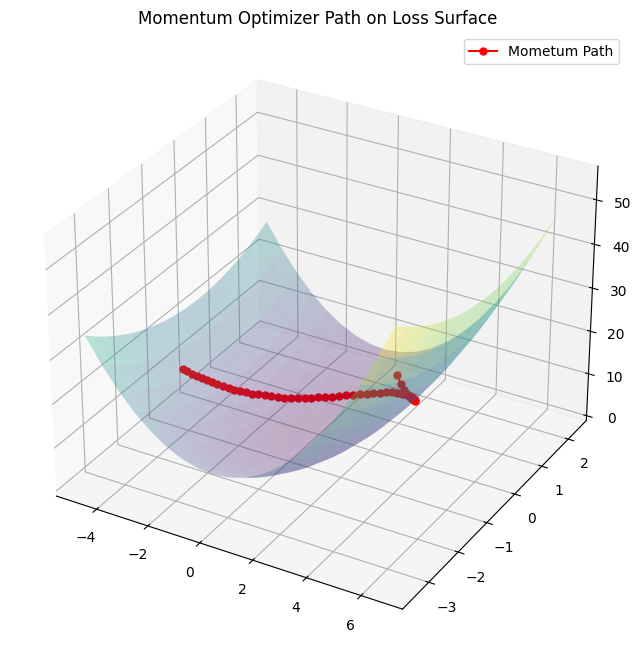

In [ ]:
# Convert All weights into 2D
all_weights = np.array(weight_callback1.weights_list1)
pca = PCA(n_components = 2)
weight_2d = pca.fit_transform(all_weights)

# Grid serface
x = np.linspace(weight_2d[:, 0].min()-1, weight_2d[:,0].max()+1, 20)
y = np.linspace(weight_2d[:, 1].min()-1, weight_2d[:, 1].max() +1, 20)
x, y = np.meshgrid(x,y)

# Cereting Dummy Loss serface
z = (x**2 + y**2)

# Ploting 3D
fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111, projection = "3d")

# Surface plot
surf = ax.plot_surface(x,y,z, cmap = "viridis", alpha = 0.3)

traj_x = weight_2d[:, 0]
traj_y = weight_2d[:, 1]
traj_z = (traj_x**2 + traj_y**2)

ax.plot(traj_x, traj_y, traj_z, color = 'red', marker = 'o', markersize = 5, label = "Mometum Path")
ax.set_title('Momentum Optimizer Path on Loss Surface')
plt.legend()
plt.show()

In [ ]:
y_pred_momentum = model_momentum.predict(x_val).round(3)

344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [ ]:
model_momentum.evaluate(x_val, y_val)

344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9035 - loss: 0.2583


[0.2583020031452179, 0.9035454392433167]

344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


/tmp/ipykernel_11492/2286668517.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


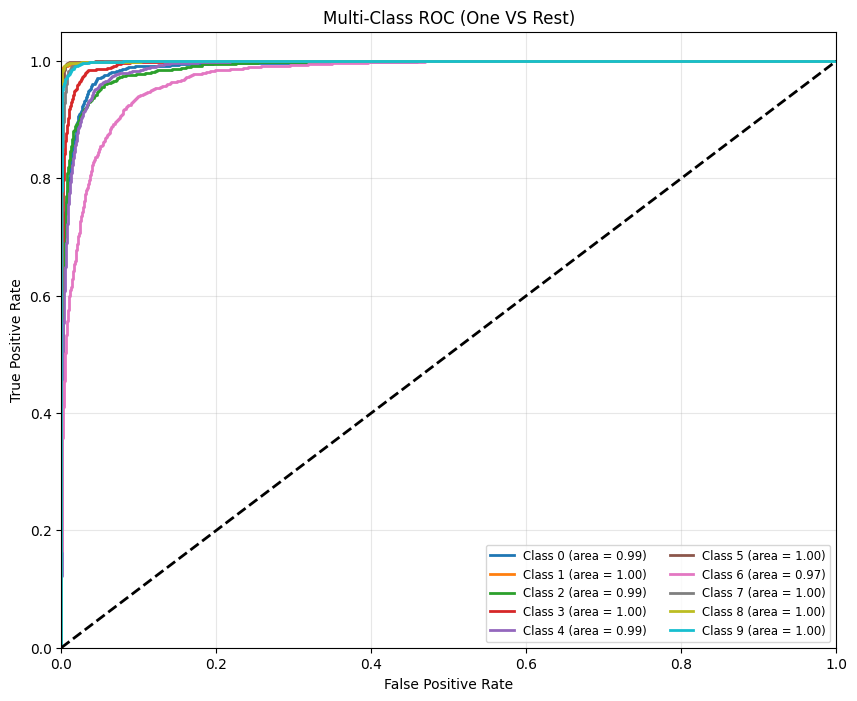

In [ ]:
classes = np.arange(10)
y_test_binarized_m = label_binarize(y_val, classes = classes)
n_classes = len(classes)

y_score_m = model_momentum.predict(x_val)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_test_binarized_m[:, i], y_score_m[:, i])
  roc_auc[i] = auc(fpr[i],tpr[i])

# Plotting
plt.figure(figsize=(10,8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
  plt.plot(fpr[i], tpr[i], color= colors(i), lw = 2, label = f"Class {i} (area = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1], 'k--', lw = 2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC (One VS Rest)")
plt.legend(loc = "lower right", fontsize = "small", ncol = 2)
plt.grid(alpha = 0.3)
plt.show()

## Visulization Of model Predict on momentum GD

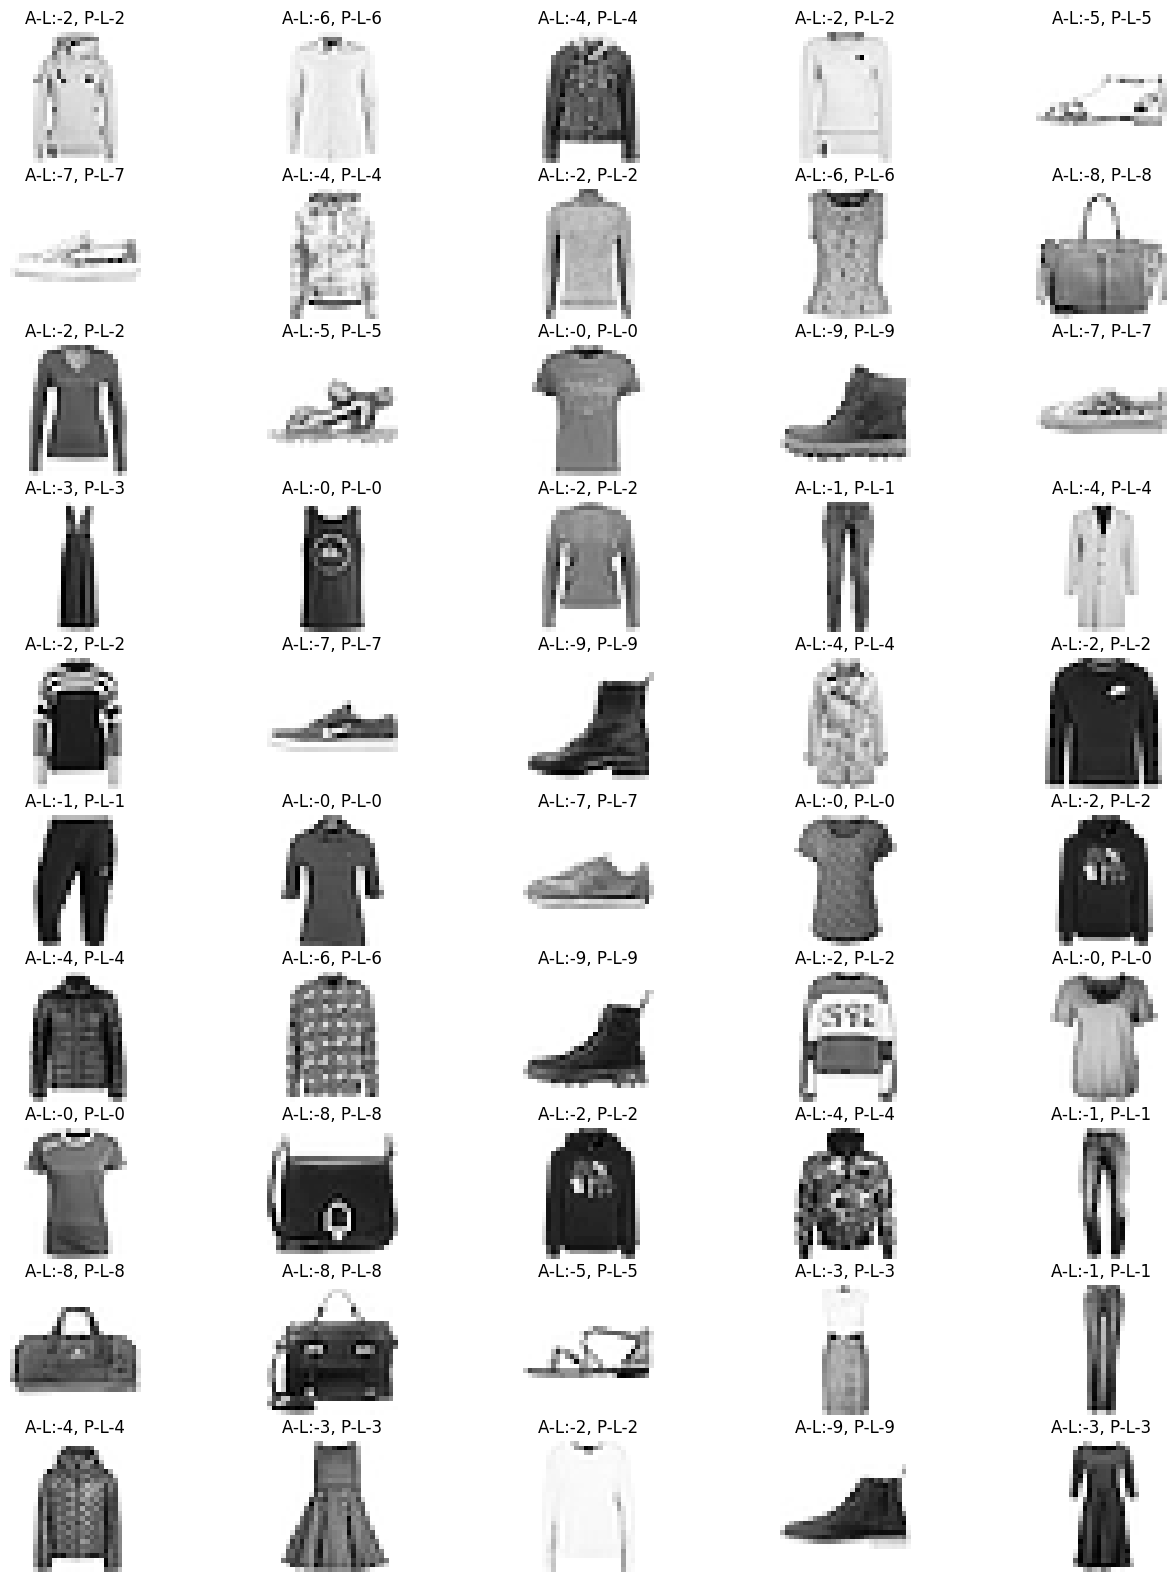

In [ ]:
plt.figure(figsize = (16,20))
j = 1
for i in np.random.randint(0,11000,50):
  plt.subplot(10,5,j)
  j +=1
  plt.imshow(x_val[i], cmap = "Greys")
  plt.title(f"A-L:-{y_val[i]}, P-L-{np.argmax(y_pred_momentum[i])}")
  plt.axis('off')

# Confusion Matrix

<Axes: >

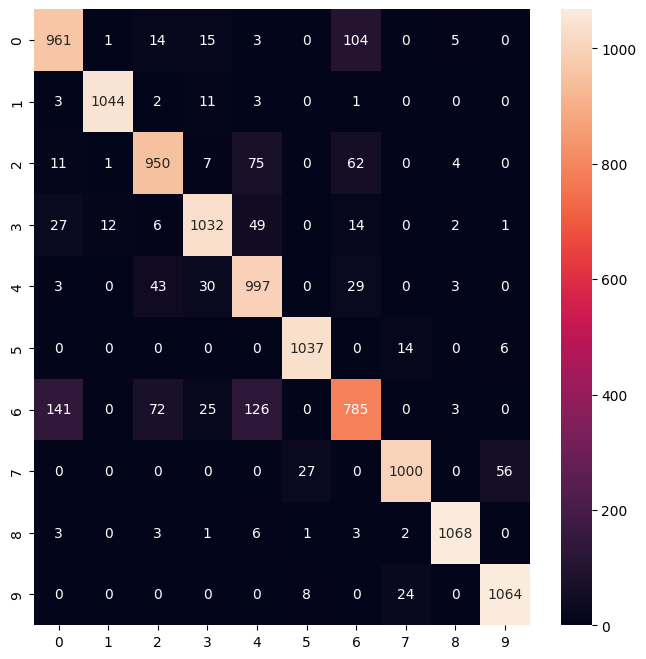

In [ ]:
plt.figure(figsize=(8,8))
y_pred_label_momentum = [np.argmax(label) for label in y_pred_momentum]
cm = confusion_matrix(y_val, y_pred_label_momentum)

sns.heatmap(cm, annot = True, fmt = 'd')

# Classification Report

In [ ]:
cr = classification_report(y_val, y_pred_label_momentum)
print(cr)

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1103
           1       0.99      0.98      0.98      1064
           2       0.87      0.86      0.86      1110
           3       0.92      0.90      0.91      1143
           4       0.79      0.90      0.84      1105
           5       0.97      0.98      0.97      1057
           6       0.79      0.68      0.73      1152
           7       0.96      0.92      0.94      1083
           8       0.98      0.98      0.98      1087
           9       0.94      0.97      0.96      1096

    accuracy                           0.90     11000
   macro avg       0.91      0.91      0.90     11000
weighted avg       0.90      0.90      0.90     11000



# Model using NAGD

In [ ]:
model_nesterov=keras.models.Sequential([keras.layers.Conv2D(filters =32,kernel_size=3, strides=(1,1), padding='valid', activation='relu', input_shape=[28,28,1]),
                         keras.layers.MaxPool2D(pool_size=(2,2)),
                         # Layers 2
                         keras.layers.Conv2D(filters = 64, kernel_size = 3, strides =(1,1), padding='same', activation='relu'),
                         keras.layers.MaxPool2D(pool_size=(2,2)),
                         # Layer 3
                         keras.layers.Conv2D(filters = 128, kernel_size = 3, strides = (1,1),padding='same', activation='relu'),
                         keras.layers.AveragePooling2D(pool_size=(2,2)),
                         # Convert into Flatten
                         keras.layers.Flatten(),
                         # ANN Model
                         keras.layers.Dense(units=100, activation='relu'),
                         keras.layers.Dense(units=100, activation='relu'),
                         keras.layers.Dense(units=100, activation='relu'),
                         # Output Layer
                         keras.layers.Dense(units=10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
opt_nagd = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov= True)

In [ ]:
model_nesterov.compile(optimizer = opt_nagd, loss = "sparse_categorical_crossentropy", metrics = ['accuracy'], jit_compile=False)

In [ ]:
class WeightsHistory2(tf.keras.callbacks.Callback):
  def on_train_begin(self, logs = None):
    self.weights_list2 = []
  def on_epoch_end(self, epoch, logs = None):
    w_all = np.concatenate([w.flatten() for w in self.model.get_weights()])
    self.weights_list2.append(w_all)
weight_callback2 = WeightsHistory2()

In [ ]:
model_nesterov.fit(x_train, y_train, epochs=50, batch_size=512, verbose=1, validation_data=(x_val, y_val), callbacks= [weight_callback2])

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 728ms/step - accuracy: 0.3150 - loss: 1.9928 - val_accuracy: 0.5043 - val_loss: 1.1139
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 723ms/step - accuracy: 0.6501 - loss: 0.9043 - val_accuracy: 0.7064 - val_loss: 0.7891
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 724ms/step - accuracy: 0.7206 - loss: 0.7408 - val_accuracy: 0.7125 - val_loss: 0.8164
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 727ms/step - accuracy: 0.7514 - loss: 0.6582 - val_accuracy: 0.7274 - val_loss: 0.6846
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 721ms/step - accuracy: 0.7705 - loss: 0.6011 - val_accuracy: 0.7664 - val_loss: 0.5988
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 67s 781ms/step - accuracy: 0.7860 - loss: 0.5573 - val_accuracy: 0.7901 - val_loss: 0.5402
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 76s 716ms/step - accuracy: 0.8006 - loss: 0.5232 - val_accuracy: 0.8055 - val_loss: 0.5108
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 724ms/step - accuracy: 0.8120 - loss: 0.4988 - val_accu

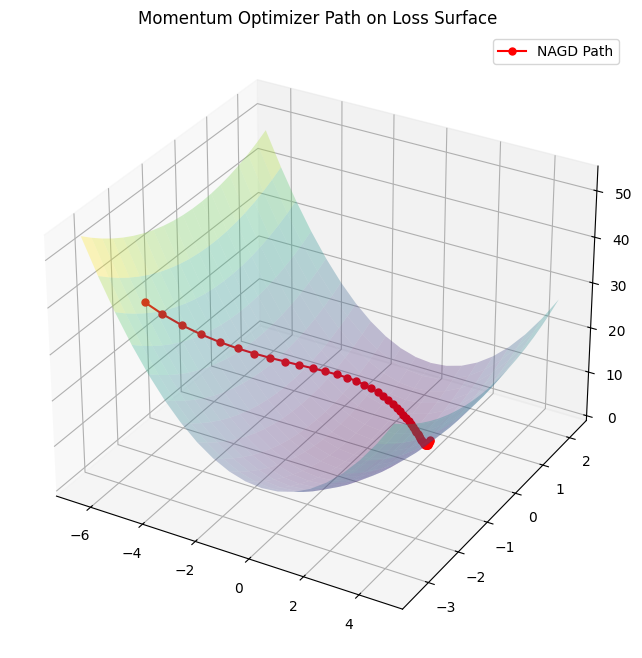

In [ ]:
# Convert All weights into 2D
all_weights = np.array(weight_callback2.weights_list2)
pca = PCA(n_components = 2)
weight_2d = pca.fit_transform(all_weights)

# Grid serface
x = np.linspace(weight_2d[:, 0].min()-1, weight_2d[:,0].max()+1, 20)
y = np.linspace(weight_2d[:, 1].min()-1, weight_2d[:, 1].max() +1, 20)
x, y = np.meshgrid(x,y)

# Cereting Dummy Loss serface
z = (x**2 + y**2)

# Ploting 3D
fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111, projection = "3d")

# Surface plot
surf = ax.plot_surface(x,y,z, cmap = "viridis", alpha = 0.3)

traj_x = weight_2d[:, 0]
traj_y = weight_2d[:, 1]
traj_z = (traj_x**2 + traj_y**2)

ax.plot(traj_x, traj_y, traj_z, color = 'red', marker = 'o', markersize = 5, label = "NAGD Path")
ax.set_title('Momentum Optimizer Path on Loss Surface')
plt.legend()
plt.show()

In [ ]:
y_pred_nagd = model_nesterov.predict(x_val).round(3)

344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step


In [ ]:
model_nesterov.evaluate(x_val, y_val)

344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8952 - loss: 0.2782


[0.27819985151290894, 0.8951818346977234]

344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


/tmp/ipykernel_11492/110545633.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


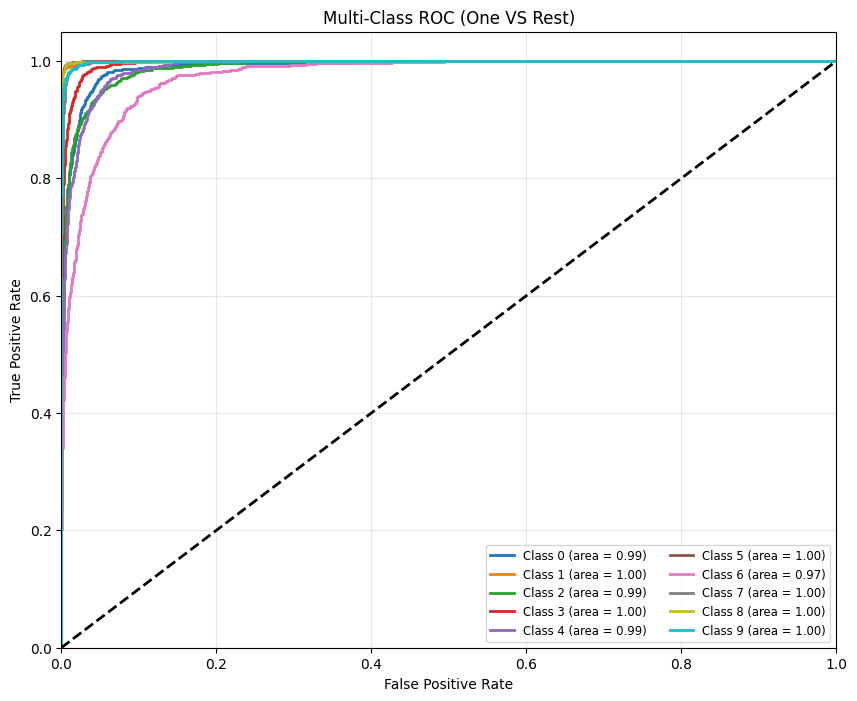

In [ ]:
classes = np.arange(10)
y_test_binarized_n = label_binarize(y_val, classes = classes)
n_classes = len(classes)

y_score_n = model_nesterov.predict(x_val)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_test_binarized_n[:, i], y_score_n[:, i])
  roc_auc[i] = auc(fpr[i],tpr[i])

# Plotting
plt.figure(figsize=(10,8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
  plt.plot(fpr[i], tpr[i], color= colors(i), lw = 2, label = f"Class {i} (area = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1], 'k--', lw = 2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC (One VS Rest)")
plt.legend(loc = "lower right", fontsize = "small", ncol = 2)
plt.grid(alpha = 0.3)
plt.show()

## Visulation of model on NAGD

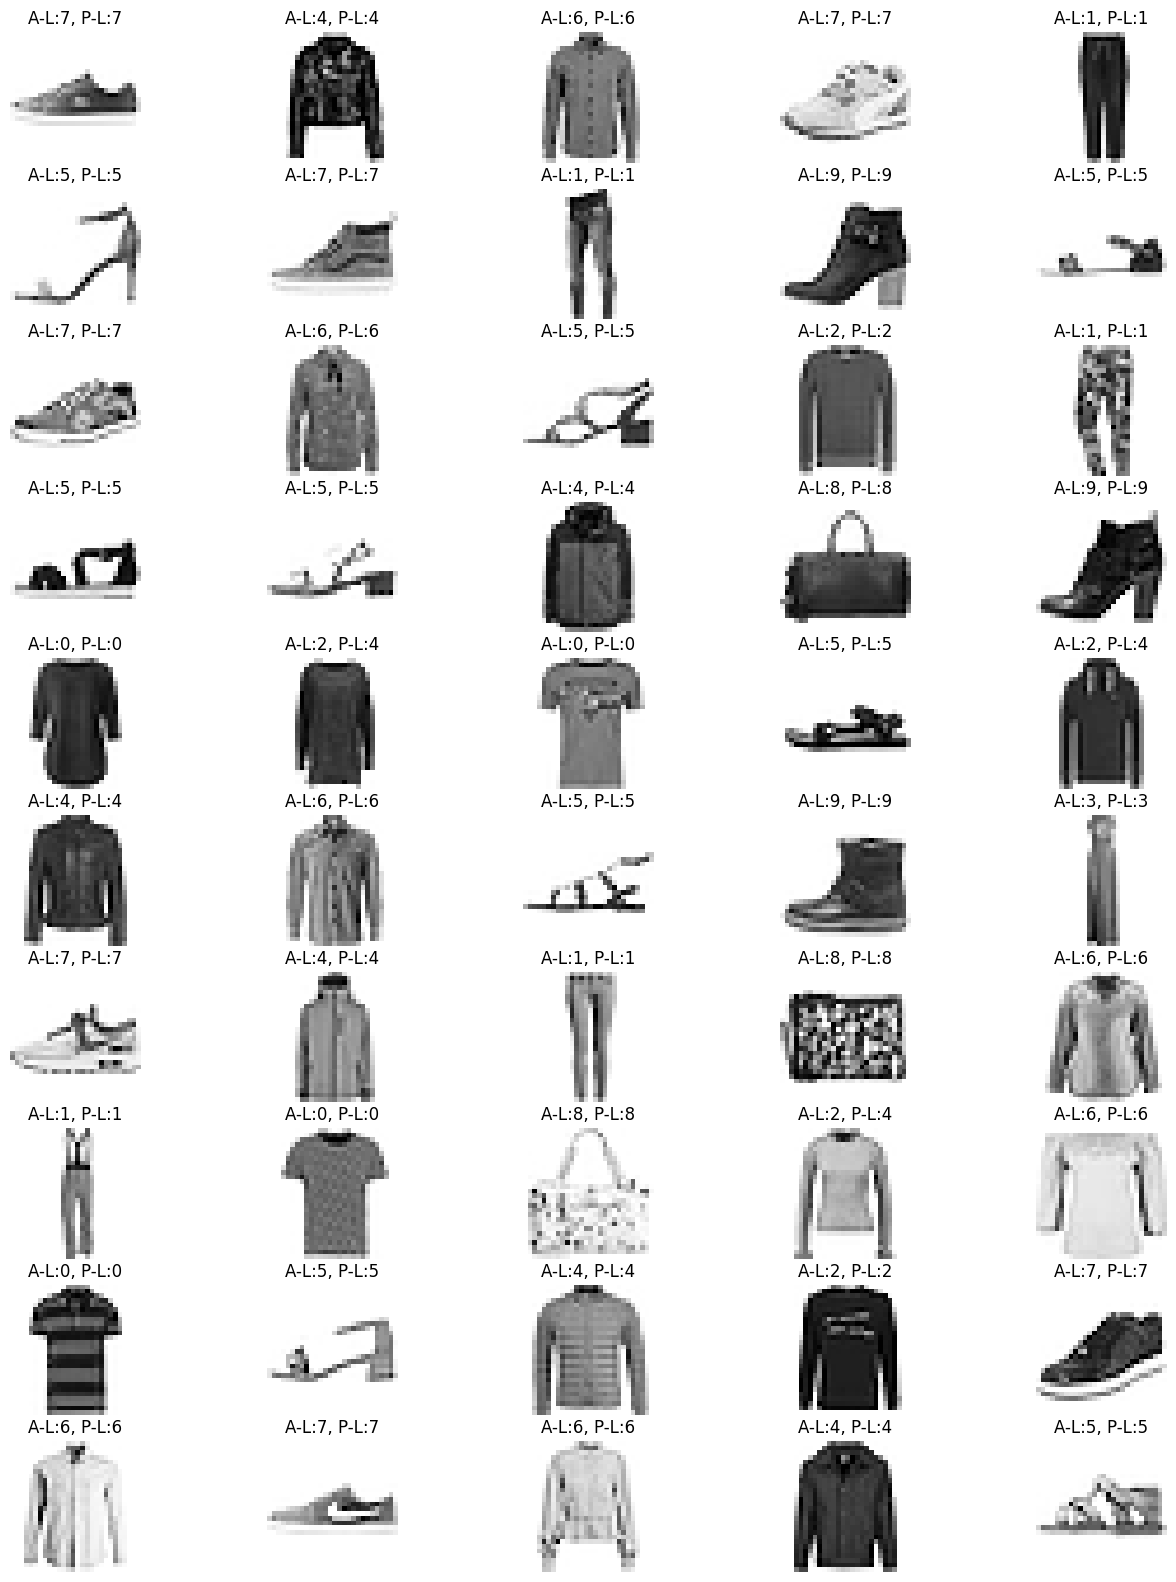

In [ ]:
plt.figure(figsize = (16,20))
j = 1
for i in np.random.randint(0,11000,50):
  plt.subplot(10,5,j)
  j += 1
  plt.imshow(x_val[i], cmap = "Greys")
  plt.title(f"A-L:{y_val[i]}, P-L:{np.argmax(y_pred_nagd[i])}")
  plt.axis("off")

# Confusion Matrics

<Axes: >

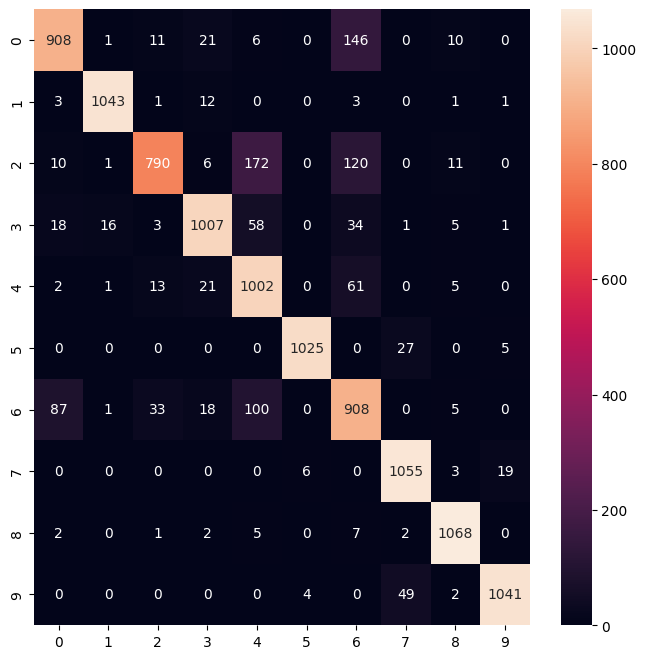

In [ ]:
plt.figure(figsize=(8,8))
y_pred_label_nesterov = [np.argmax(label) for label in y_pred_nagd]
cm = confusion_matrix(y_val, y_pred_label_nesterov)

sns.heatmap(cm, annot = True, fmt = 'd')

# Classification Report

In [ ]:
cr = classification_report(y_val, y_pred_label_nesterov)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1103
           1       0.98      0.98      0.98      1064
           2       0.93      0.71      0.81      1110
           3       0.93      0.88      0.90      1143
           4       0.75      0.91      0.82      1105
           5       0.99      0.97      0.98      1057
           6       0.71      0.79      0.75      1152
           7       0.93      0.97      0.95      1083
           8       0.96      0.98      0.97      1087
           9       0.98      0.95      0.96      1096

    accuracy                           0.90     11000
   macro avg       0.90      0.90      0.90     11000
weighted avg       0.90      0.90      0.90     11000

